#### Classes em Python

De forma bem simples, `Classes` são estruturas de dados reaproveitáveis que são utilizadas como modelos para a criação de objetos. Uma `Classe` define atributos (variáveis) e métodos (funções) que os objetos derivados dessa classe terão. Já `objetos` são instâncias de uma classe, ou seja, elementos concretos que seguem a estrutura definida pela classe.

Para criar essa estrutura usamos o comando `class`. Na criação de uma classe, podemos implementar características relacionadas aos nossos objetos assim como "comandos" (método) que esse objeto pode fazer.

In [1]:
# Exemplo prático: Vamos criar a classe ImagemSatelite:

class ImagemSatelite:
    pass

A primeira coisa que deve ser feita é definir os parâmetros de inicialização da classe, ou seja, seus atributos. Isso é feito com a função `__init__()`. Por padrão todas as caracteríticas do objeto têm que ser definidas nessa função. A variável `self` apenas indica que a informação se refere à propria classe.

Vamos definir as classes da seguinte forma:

- Atributos: path, dataset, n_bands;
- Métodos:  stats, hist, normalize, close;

In [2]:
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
arr = np.random.rand(5)


In [9]:
class ImagemSatelite:
    
    def __init__(self, path): #Definir os atributos da minha classe
        self.path = path
        with rasterio.open(path) as scr:
           self.n_bands = scr.count #Número de bandas da imagem
           self.dataset = scr.read() #Leitura
        
        
    def stats(self):
        """
        Calcula as estatísticas (média, desvio padrão, valor mínimo e máximo) para todas as bandas.
        """
        stats = []
        for i in range(self.n_bands):
            band = self.dataset[i,:,:] #Acessando a banda 
            mean = np.mean(band)
            std = np.std(band)
            min_val = np.min(band)
            max_val = np.max(band)
            n_NoData = np.isnan(band).sum()
            stats.append({'Banda': i, 'Média': mean, 'Desvio Padrão': std, 'Mínimo': min_val, 'Máximo': max_val,'Qnd. NoData':n_NoData})
           
        
        df_stats = pd.DataFrame(stats)

        return df_stats
    
    def hist(self, bins=50):
        """
        Calcula os histogramas de todas as bandas.
        """
        plt.figure(figsize=(12, 8))
        for i in range(self.n_bands):
            band = self.dataset[i, :, :]  # Acessa a banda i
            plt.subplot(2, 3, i+1)  # Ajuste o layout de acordo com o número de bandas
            plt.hist(band.flatten(), bins=bins, color='blue', alpha=0.7)
            plt.title(f'Histograma - Banda {i+1}')
            plt.xlabel('Valor de Pixel')
            plt.ylabel('Frequência')
        plt.tight_layout()
        plt.show()
    
    def normalize(self):
        """
        Normaliza todas as bandas da imagem para o intervalo [0, 1].
        """
        normalized_bands = []  # Inicializa uma lista vazia para armazenar as bandas normalizadas
        for i in range(self.n_bands):
            band = self.dataset[i, :, :]  # Acessa a banda i
            min_val = np.min(band)
            max_val = np.max(band)
            normalized_band = (band - min_val) / (max_val - min_val)
            normalized_bands.append(normalized_band)  # Adiciona a banda normalizada à lista

        # Empilha as bandas em um único array e retorna
        return np.stack(normalized_bands, axis=0) 
    

    def plot_bands(self):
        """
        Plota todas as bandas da imagem separadamente.
        """
        plt.figure(figsize=(12, 8))
        for i in range(self.n_bands):
            band = self.dataset[i, :, :]  # Acessa a banda i
            plt.subplot(2, 3, i+1)  # Ajuste o layout de acordo com o número de bandas
            plt.imshow(band, cmap='gray')
            plt.title(f'Banda {i+1}')
            plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    def plot_composition(self, band_indices=[2, 1, 0]):
        
        # É possível fazer 
        # Verifica se o número de bandas é suficiente para a composição
        if len(band_indices) != 3:
            print("A composição precisa de 3 bandas.")
            return

        if max(band_indices) > self.n_bands:
            print("Índices de bandas inválidos. A imagem possui apenas", self.n_bands, "bandas.")
            return
        
        # Acessando as bandas selecionadas
        red = self.dataset[band_indices[0], :, :]  # Banda R
        green = self.dataset[band_indices[1], :, :]  # Banda G
        blue = self.dataset[band_indices[2], :, :]  # Banda B

        # Normaliza as bandas para o intervalo [0, 1] > O Matplotlib exige que seja assim...
        red = (red - np.min(red)) / (np.max(red) - np.min(red))
        green = (green - np.min(green)) / (np.max(green) - np.min(green))
        blue = (blue - np.min(blue)) / (np.max(blue) - np.min(blue))

        # Criação da composição RGB
        rgb_composition = np.stack([red, green, blue], axis=-1)
        
        # Plota a imagem composta
        plt.figure(figsize=(8, 8))
        plt.imshow(rgb_composition)
        plt.title(f'Composição RGB (Bandas {band_indices[0]+1}, {band_indices[1]+1}, {band_indices[2]+1})')
        plt.axis('off')
        plt.show()

Instanciando os objetos por meio da classe `ImagemSatelite`:

In [10]:
image_path = 'G:/Meu Drive/UNIFESP/forest_eyes/4.imagens/imagens_processadas/data_sbsr/processamento_2/LANDSAT_8.TIF'

In [11]:
imagem_1 = ImagemSatelite(image_path) #INSTANCIANDO UM OBJETO

Podemos observar os métodos da classe `ImageSatelite` com a função `dir`.

In [12]:
dir(ImagemSatelite)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'hist',
 'normalize',
 'plot_bands',
 'plot_composition',
 'stats']

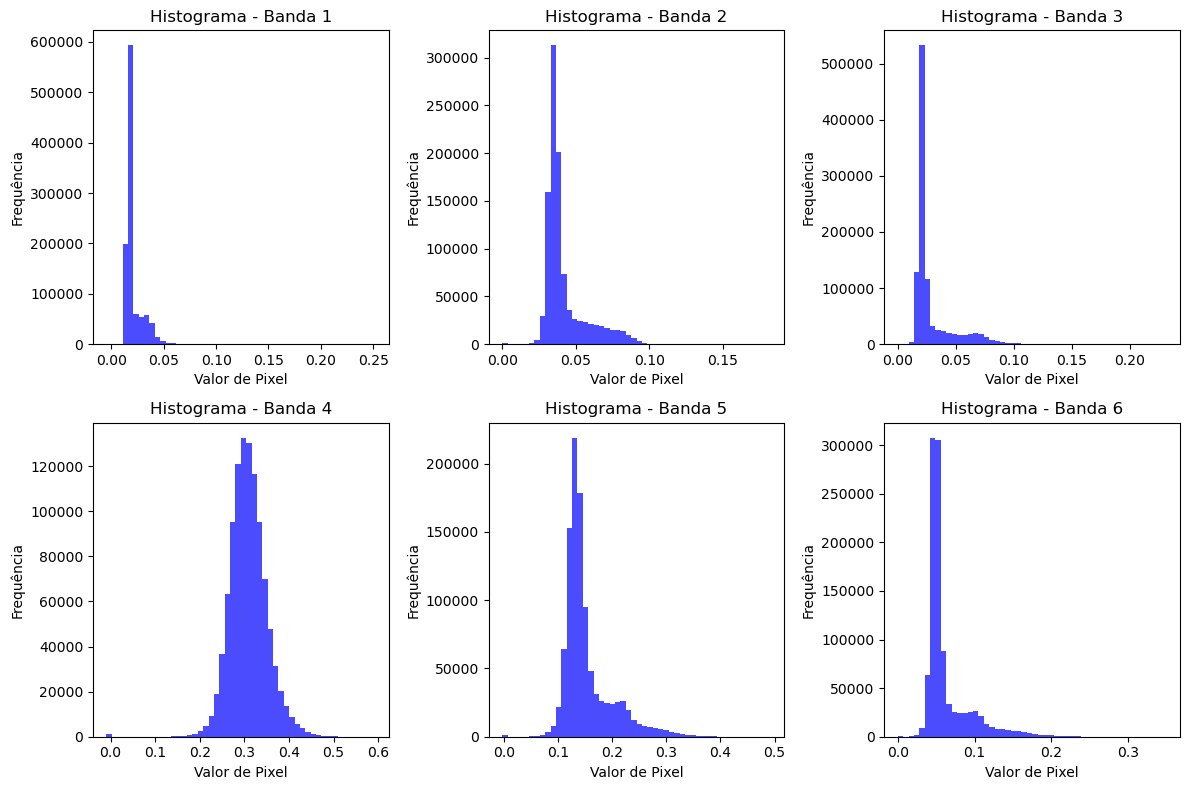

In [13]:
imagem_1.hist()

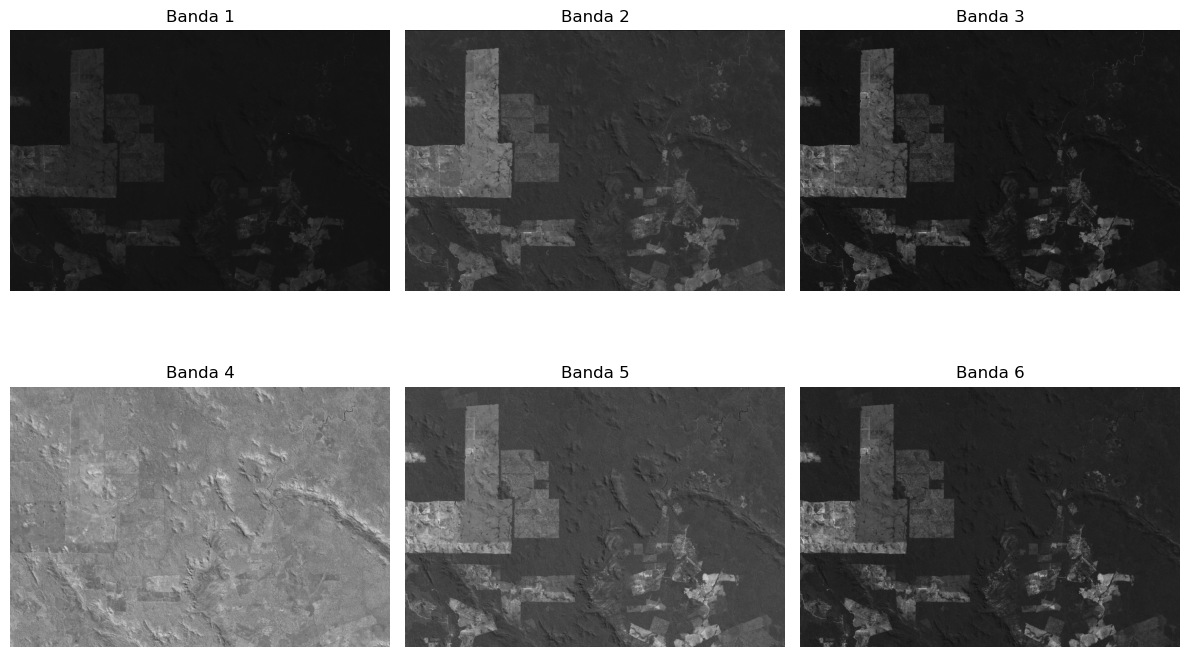

In [14]:
imagem_1.plot_bands()

In [15]:
imagem_1.normalize()

array([[[0.01860834, 0.01860834, 0.01860834, ..., 0.01860834,
         0.01860834, 0.01860834],
        [0.08054847, 0.08547559, 0.08590404, ..., 0.08204804,
         0.08236935, 0.07990579],
        [0.08558273, 0.08633249, 0.08419023, ..., 0.07990579,
         0.08376178, 0.08611826],
        ...,
        [0.0845116 , 0.08054847, 0.07615682, ..., 0.09050991,
         0.08986723, 0.0827978 ],
        [0.09222365, 0.0879392 , 0.08247649, ..., 0.0836547 ,
         0.08322625, 0.08483291],
        [0.09222365, 0.09811488, 0.08643963, ..., 0.07637104,
         0.07529992, 0.07829907]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.16732764, 0.21155629, 0.1987691 , ..., 0.1971143 ,
         0.1882385 , 0.17755744],
        [0.19576041, 0.19771606, 0.20132658, ..., 0.18568109,
         0.19485778, 0.19891956],
        ...,
        [0.20764498, 0.21200764, 0.18899065, ..., 0.26977572,
         0.2624042 , 0.2383342 ],
        [0.2

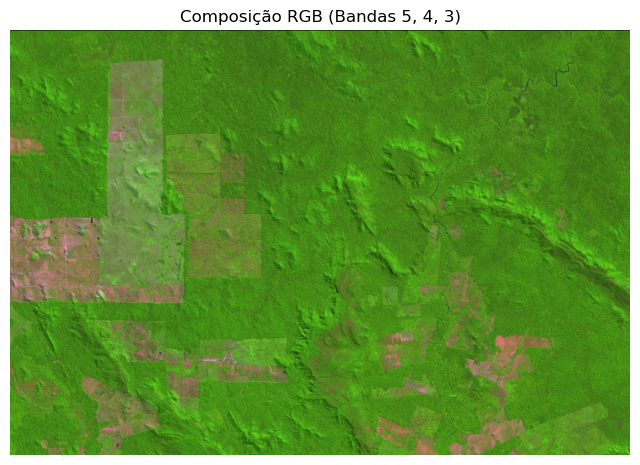

In [18]:
imagem_1.plot_composition([4,3,2])

In [ ]:
imagem_1.classification()

,Banda,Média,Desvio Padrão,Mínimo,Máximo,Qnd. NoData
0,0,0.020377,0.007936,-0.004778,0.251962,0
1,1,0.042072,0.014345,0.000000,0.182800,0
2,2,0.029054,0.017957,0.000000,0.231640,0
3,3,0.309179,0.041784,-0.009123,0.593513,0
4,4,0.152922,0.045028,-0.002907,0.493275,0
5,5,0.062827,0.029767,0.000000,0.349808,0
